Volatility Regimes - Martha McQuillan

1/23/2026

In [2]:
import sys
from pathlib import Path

ROOT = Path().resolve().parents[0]
sys.path.append(str(ROOT))

In [3]:
from src.data_loader import load_prices_csv, compute_log_returns
from src.volatility_regimes import VolRegimeConfig, build_regime_frame, regime_summary, regime_transition_matrix

prices = load_prices_csv("btc_eth_prices.csv")
rets = compute_log_returns(prices)

btc = rets["btc_usd_logret"]

cfg = VolRegimeConfig(window=30, q_low=0.33, q_high=0.67)
df = build_regime_frame(btc, cfg)

regime_summary(df)
regime_transition_matrix(df["vol_regime"])


vol_regime,HighVol,LowVol,MidVol
vol_regime,,,
HighVol,0.949948,0.001043,0.049009
LowVol,0.001044,0.953027,0.045929
MidVol,0.046512,0.045501,0.907988


The analysis reveals strong evidence of volatility clustering in Bitcoin returns. Using a 30-day realized volatility measure, distinct low-, medium-, and high-volatility regimes emerge, with substantial persistence across time.

The regime transition matrix shows that volatility states are highly stable: once Bitcoin enters a high-volatility regime, it remains there with approximately 95% day-to-day probability, with similarly strong persistence observed in low-volatility periods. This indicates that volatility dynamics are not memoryless, but instead evolve in sustained regimes.

In contrast to the return-level ARIMA analysis, which finds limited short-horizon predictability in mean returns, volatility exhibits structured behavior that is more amenable to modeling. This suggests that, for crypto markets, understanding and managing risk regimes may be more informative than attempting to forecast returns directly.

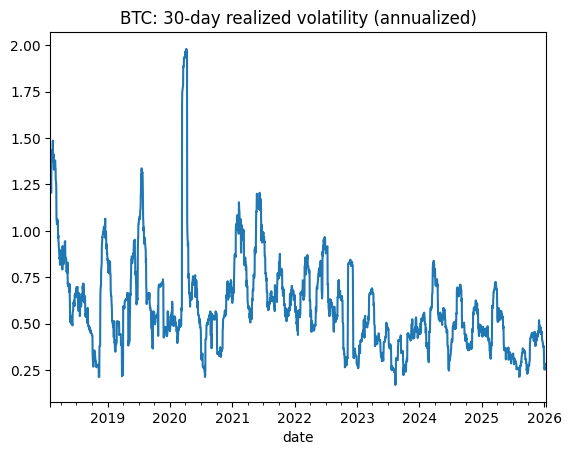

In [4]:
import matplotlib.pyplot as plt

plt.figure()
df["realized_vol"].plot()
plt.title("BTC: 30-day realized volatility (annualized)")
plt.show()
